# Parasite Worm Detection using YOLOv8 + ResNet
**Course:** Advanced Deep Learning (IT6328E) 
**Topic:** Object Detection on Parasite Worm/Egg Dataset

## Pipeline Overview
1. **YOLOv8** — Detect parasite eggs/worms in microscopy images
2. **ResNet50** — Classify detected regions into specific species

---

## 1. Environment Setup

In [12]:
# Check GPU availability
!nvidia-smi

Tue Mar 17 13:21:28 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [13]:
# Install required libraries
!pip install -q ultralytics gdown torchvision matplotlib seaborn scikit-learn pillow tqdm

In [14]:
import os
import glob
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.datasets import ImageFolder

from ultralytics import YOLO
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Using device: cuda
PyTorch version: 2.10.0+cu128
CUDA available: True


## 2. Download Dataset from Google Drive

In [15]:
import gdown
import zipfile

DATASET_URL = "https://drive.google.com/drive/folders/1EbKDSATBGm01fjUF0HJd14vGt9PdsIC9"
DATASET_DIR = "/content/dataset"
EXTRACTED_DIR = "/content/dataset_extracted"

# Download the entire shared folder
os.makedirs(DATASET_DIR, exist_ok=True)
gdown.download_folder(DATASET_URL, output=DATASET_DIR, quiet=False)

# Extract all ZIP files
os.makedirs(EXTRACTED_DIR, exist_ok=True)
for zf in Path(DATASET_DIR).glob("*.zip"):
    print(f"\nExtracting {zf.name}...")
    with zipfile.ZipFile(zf, 'r') as z:
        z.extractall(EXTRACTED_DIR)
    print(f"  ✅ Extracted to {EXTRACTED_DIR}")

# Copy JSON annotation files too
for jf in Path(DATASET_DIR).glob("*.json"):
    shutil.copy2(jf, EXTRACTED_DIR)

# Update DATASET_DIR to extracted location
DATASET_DIR = EXTRACTED_DIR
print(f"\n📁 Dataset directory: {DATASET_DIR}")
!ls -la {DATASET_DIR}

Retrieving folder contents


Processing file 1s0EY2aKatBd9bR0vDwrDOWJ9JMrWRknR Chula-ParasiteEgg-11_test.zip
Processing file 1_AnLsRNxk97eM3Ws1mraQ1BG76BEtkwe Chula-ParasiteEgg-11.zip
Processing file 19hdA913kEEMtOf0WoJxpiIhX3ERI6YLw test_labels_200.json


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1s0EY2aKatBd9bR0vDwrDOWJ9JMrWRknR
From (redirected): https://drive.google.com/uc?id=1s0EY2aKatBd9bR0vDwrDOWJ9JMrWRknR&confirm=t&uuid=bdf7217e-06ee-4694-998a-09a3de9da548
To: /content/dataset/Chula-ParasiteEgg-11_test.zip
100%|██████████| 2.44G/2.44G [00:33<00:00, 72.4MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1_AnLsRNxk97eM3Ws1mraQ1BG76BEtkwe
From (redirected): https://drive.google.com/uc?id=1_AnLsRNxk97eM3Ws1mraQ1BG76BEtkwe&confirm=t&uuid=567bea34-cc51-43db-be37-787a53ce79fe
To: /content/dataset/Chula-ParasiteEgg-11.zip
100%|██████████| 9.12G/9.12G [02:21<00:00, 64.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=19hdA913kEEMtOf0WoJxpiIhX3ERI6YLw
To: /content/dataset/test_labels_200.json
100%|██████████| 442k/442k [00:00<00:00, 115MB/s]
Download completed



Extracting Chula-ParasiteEgg-11.zip...
  ✅ Extracted to /content/dataset_extracted

Extracting Chula-ParasiteEgg-11_test.zip...
  ✅ Extracted to /content/dataset_extracted

📁 Dataset directory: /content/dataset_extracted
total 448
drwxr-xr-x 4 root root   4096 Mar 17 13:26 .
drwxr-xr-x 1 root root   4096 Mar 17 13:24 ..
drwxr-xr-x 3 root root   4096 Mar 17 13:24 Chula-ParasiteEgg-11
drwxr-xr-x 3 root root   4096 Mar 17 13:26 test
-rw-r--r-- 1 root root 442116 Apr  6  2025 test_labels_200.json


## 3. Explore Dataset Structure\n\nLet's inspect what we downloaded — folder structure, file types, annotation format, and class distribution.

In [16]:
# Explore the downloaded dataset structure
def explore_directory(path, indent=0, max_files=10):
    """Print directory tree with file counts."""
    path = Path(path)
    if not path.exists():
        print(f"  {'  ' * indent}[NOT FOUND] {path}")
        return

    items = sorted(path.iterdir())
    dirs = [i for i in items if i.is_dir()]
    files = [i for i in items if i.is_file()]

    print(f"{'  ' * indent}📁 {path.name}/ ({len(files)} files, {len(dirs)} subdirs)")

    # Show first few files
    for f in files[:max_files]:
        size = f.stat().st_size / 1024  # KB
        print(f"{'  ' * (indent+1)}📄 {f.name} ({size:.1f} KB)")
    if len(files) > max_files:
        print(f"{'  ' * (indent+1)}... and {len(files) - max_files} more files")

    # Recurse into subdirectories
    for d in dirs:
        explore_directory(d, indent + 1, max_files=5)

print("=" * 60)
print("DATASET STRUCTURE")
print("=" * 60)
explore_directory(DATASET_DIR)

DATASET STRUCTURE
📁 dataset_extracted/ (1 files, 2 subdirs)
  📄 test_labels_200.json (431.8 KB)
  📁 Chula-ParasiteEgg-11/ (0 files, 1 subdirs)
    📁 Chula-ParasiteEgg-11/ (1 files, 1 subdirs)
      📄 labels.json (5135.7 KB)
      📁 data/ (11000 files, 0 subdirs)
        📄 Ascaris lumbricoides_0001.jpg (142.5 KB)
        📄 Ascaris lumbricoides_0002.jpg (243.4 KB)
        📄 Ascaris lumbricoides_0003.jpg (184.3 KB)
        📄 Ascaris lumbricoides_0004.jpg (95.6 KB)
        📄 Ascaris lumbricoides_0005.jpg (412.5 KB)
        ... and 10995 more files
  📁 test/ (0 files, 1 subdirs)
    📁 data/ (2200 files, 1 subdirs)
      📄 0001.jpg (281.6 KB)
      📄 0002.jpg (1853.4 KB)
      📄 0003.jpg (1321.8 KB)
      📄 0004.jpg (1376.2 KB)
      📄 0005.jpg (1243.2 KB)
      ... and 2195 more files
      📁 irfanview/ (1 files, 0 subdirs)
        📄 i_view32.ini (0.5 KB)


In [17]:
# Analyze file types and detect annotation format
def analyze_dataset(path):
    """Detect dataset type: YOLO, COCO, VOC, or classification (folder-based)."""
    path = Path(path)
    all_files = list(path.rglob("*"))
    files_only = [f for f in all_files if f.is_file()]
    dirs_only = [f for f in all_files if f.is_dir()]

    # Count file extensions
    ext_counter = Counter(f.suffix.lower() for f in files_only)

    print("=" * 60)
    print("FILE TYPE ANALYSIS")
    print("=" * 60)
    print(f"Total files: {len(files_only)}")
    print(f"Total directories: {len(dirs_only)}")
    print(f"\nFile extensions:")
    for ext, count in ext_counter.most_common():
        print(f"  {ext or '(no ext)'}: {count}")

    # Detect format
    print(f"\n{'=' * 60}")
    print("FORMAT DETECTION")
    print("=" * 60)

    has_txt = any(f.suffix == '.txt' for f in files_only)
    has_xml = any(f.suffix == '.xml' for f in files_only)
    has_json = any(f.suffix == '.json' for f in files_only)
    has_yaml = any(f.suffix in ('.yaml', '.yml') for f in files_only)
    has_images = any(f.suffix.lower() in ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff') for f in files_only)

    image_dirs = set()
    for f in files_only:
        if f.suffix.lower() in ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'):
            image_dirs.add(f.parent.name)

    if has_yaml and has_txt:
        print("✅ Likely YOLO format (has .yaml config + .txt labels)")
    elif has_json:
        print("🔍 Possibly COCO format (has .json annotations)")
    elif has_xml:
        print("🔍 Possibly Pascal VOC format (has .xml annotations)")
    elif has_images and len(image_dirs) > 1:
        print("🔍 Possibly classification format (images in class folders)")
    else:
        print("⚠️ Unknown format — manual inspection needed")

    print(f"\nDirectories containing images: {image_dirs}")

    # Show sample annotation if exists
    if has_txt:
        txt_files = [f for f in files_only if f.suffix == '.txt' and f.name != 'classes.txt']
        if txt_files:
            print(f"\n--- Sample .txt annotation ({txt_files[0].name}) ---")
            print(txt_files[0].read_text()[:500])

    if has_json:
        json_files = [f for f in files_only if f.suffix == '.json']
        if json_files:
            import json
            print(f"\n--- Sample .json keys ({json_files[0].name}) ---")
            with open(json_files[0]) as jf:
                data = json.load(jf)
                if isinstance(data, dict):
                    print(f"Keys: {list(data.keys())}")
                elif isinstance(data, list):
                    print(f"List of {len(data)} items, first item keys: {list(data[0].keys()) if data else 'empty'}")

    if has_yaml:
        yaml_files = [f for f in files_only if f.suffix in ('.yaml', '.yml')]
        for yf in yaml_files:
            print(f"\n--- YAML config ({yf.name}) ---")
            print(yf.read_text()[:500])

    if has_xml:
        xml_files = [f for f in files_only if f.suffix == '.xml']
        if xml_files:
            print(f"\n--- Sample .xml annotation ({xml_files[0].name}) ---")
            print(xml_files[0].read_text()[:500])

    # Check for classes.txt
    classes_files = [f for f in files_only if f.name == 'classes.txt']
    if classes_files:
        print(f"\n--- classes.txt ---")
        print(classes_files[0].read_text())

    return ext_counter, image_dirs

ext_counter, image_dirs = analyze_dataset(DATASET_DIR)

FILE TYPE ANALYSIS
Total files: 13203
Total directories: 6

File extensions:
  .jpg: 13200
  .json: 2
  .ini: 1

FORMAT DETECTION
🔍 Possibly COCO format (has .json annotations)

Directories containing images: {'data'}

--- Sample .json keys (test_labels_200.json) ---
Keys: ['info', 'licenses', 'categories', 'images', 'annotations']


Total images found: 13200

Images per directory:
  data: 13200 images


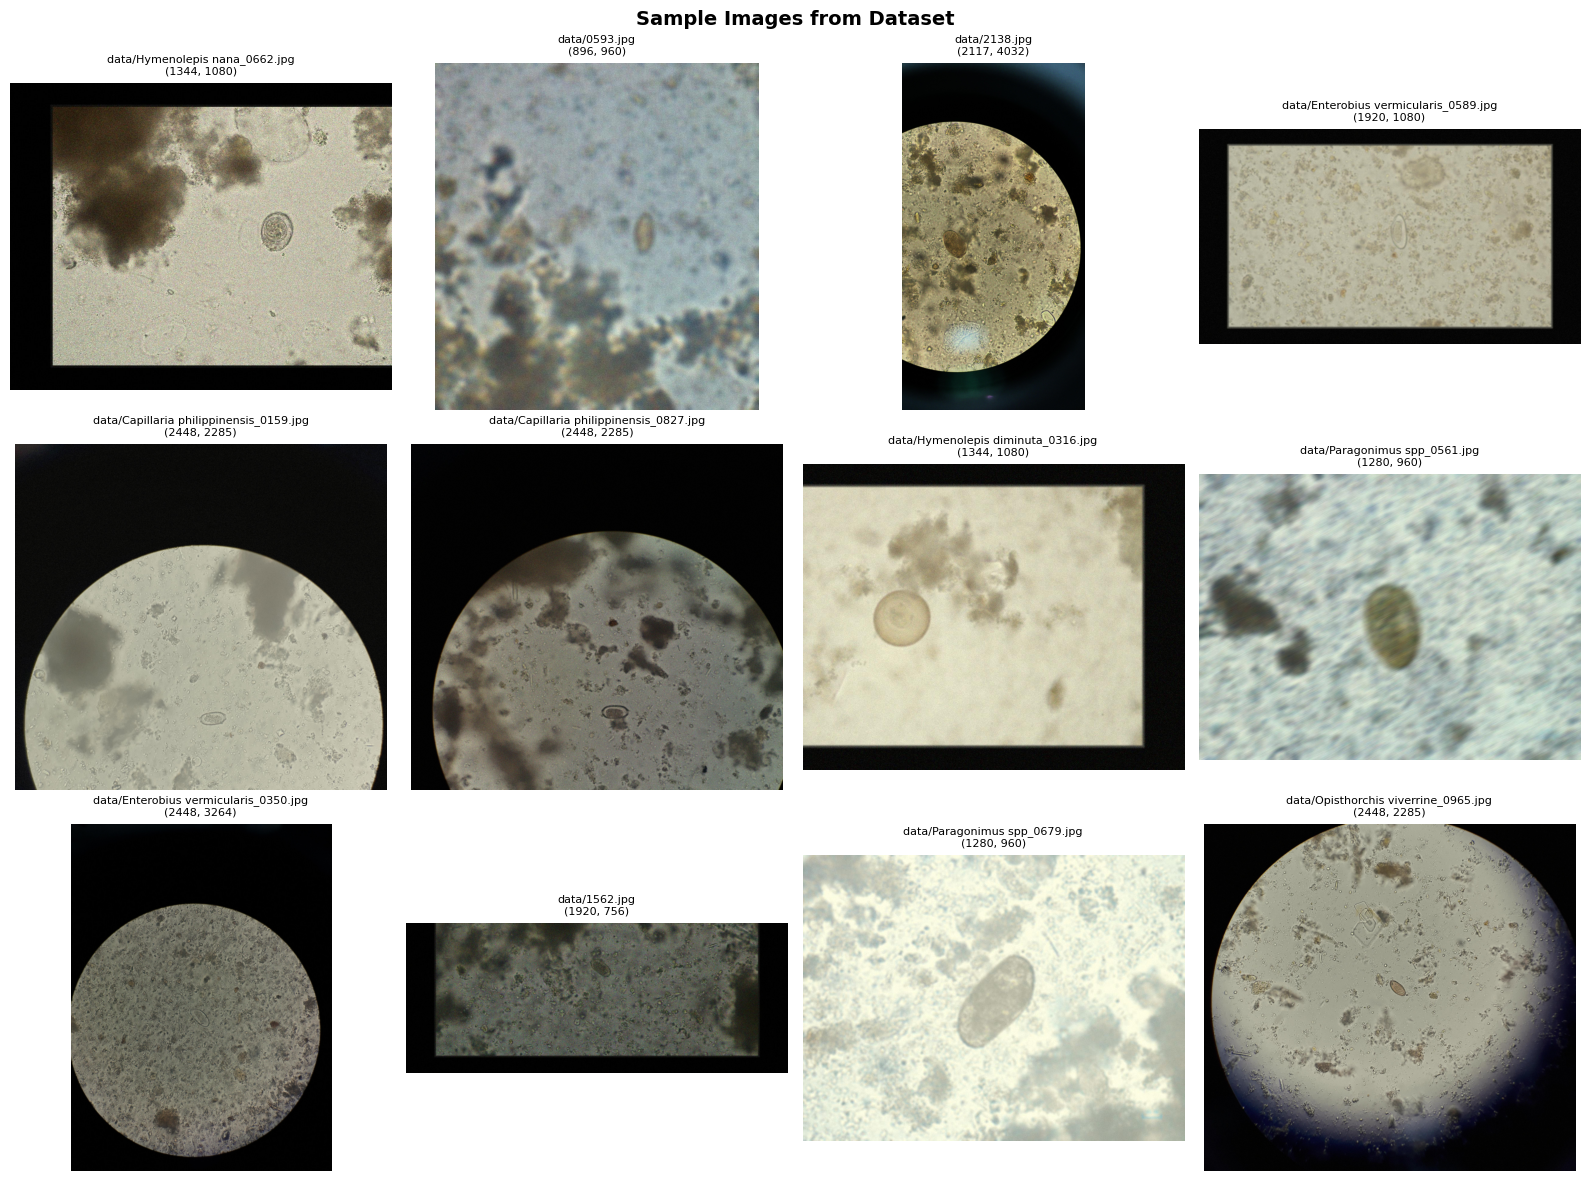

In [18]:
# Visualize sample images from the dataset
def show_sample_images(dataset_dir, n_samples=12, figsize=(16, 12)):
    """Display random sample images from the dataset."""
    path = Path(dataset_dir)
    image_exts = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}
    all_images = [f for f in path.rglob("*") if f.suffix.lower() in image_exts]

    if not all_images:
        print("No images found!")
        return

    print(f"Total images found: {len(all_images)}")

    # Group by parent directory
    groups = {}
    for img in all_images:
        parent = img.parent.name
        groups.setdefault(parent, []).append(img)

    print(f"\nImages per directory:")
    for dirname, imgs in sorted(groups.items()):
        print(f"  {dirname}: {len(imgs)} images")

    # Show samples
    samples = random.sample(all_images, min(n_samples, len(all_images)))
    cols = 4
    rows = (len(samples) + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.flatten() if rows > 1 else [axes] if rows == 1 and cols == 1 else axes.flatten()

    for idx, ax in enumerate(axes):
        if idx < len(samples):
            img = Image.open(samples[idx])
            ax.imshow(img)
            ax.set_title(f"{samples[idx].parent.name}/{samples[idx].name}\n{img.size}", fontsize=8)
        ax.axis('off')

    plt.suptitle("Sample Images from Dataset", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_sample_images(DATASET_DIR)

## 4. Data Preparation
Based on the dataset inspection above, we prepare the data for both:
- **YOLOv8**: Object detection (YOLO format with bounding box labels)
- **ResNet50**: Image classification (class folders)
> **Note:** Run the cells in Section 3 first to understand the dataset structure. The preparation code below handles common formats automatically. If the dataset uses an unusual format, adapt accordingly.

In [19]:
# ============================================================
# DATA PREPARATION — Handle COCO, YOLO, or Classification formats
# ============================================================

import json as json_module

WORK_DIR = "/content/parasite_project"
YOLO_DIR = os.path.join(WORK_DIR, "yolo_dataset")
CLF_DIR = os.path.join(WORK_DIR, "clf_dataset")
os.makedirs(WORK_DIR, exist_ok=True)

def find_all_images(root):
    """Find all image files recursively."""
    exts = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}
    return [f for f in Path(root).rglob("*") if f.suffix.lower() in exts]

def find_all_labels(root, ext='.txt'):
    """Find all label files recursively."""
    return [f for f in Path(root).rglob(f"*{ext}") if f.name != 'classes.txt']

def find_coco_json(root):
    """Find COCO-format JSON annotation files."""
    candidates = []
    for jf in Path(root).rglob("*.json"):
        try:
            with open(jf) as f:
                data = json_module.load(f)
            if isinstance(data, dict) and 'annotations' in data and 'images' in data:
                candidates.append(jf)
        except:
            pass
    return candidates

# Scan dataset
all_images = find_all_images(DATASET_DIR)
all_labels = find_all_labels(DATASET_DIR)
coco_jsons = find_coco_json(DATASET_DIR)

print(f"Images found: {len(all_images)}")
print(f"YOLO label files (.txt): {len(all_labels)}")
print(f"COCO JSON files: {len(coco_jsons)}")
for jf in coco_jsons:
    with open(jf) as f:
        data = json_module.load(f)
    print(f"  {jf.name}: {len(data.get('images',[]))} images, "
          f"{len(data.get('annotations',[]))} annotations, "
          f"{len(data.get('categories',[]))} categories")
    print(f"  Categories: {[c['name'] for c in data.get('categories', [])]}")

Images found: 13200
YOLO label files (.txt): 0
COCO JSON files: 2
  test_labels_200.json: 2200 images, 2228 annotations, 11 categories
  Categories: ['Ascaris lumbricoides', 'Capillaria philippinensis', 'Enterobius vermicularis', 'Fasciolopsis buski', 'Hookworm egg', 'Hymenolepis diminuta', 'Hymenolepis nana', 'Opisthorchis viverrine', 'Paragonimus spp', 'Taenia spp. egg', 'Trichuris trichiura']
  labels.json: 11000 images, 11031 annotations, 11 categories
  Categories: ['Ascaris lumbricoides', 'Capillaria philippinensis', 'Enterobius vermicularis', 'Fasciolopsis buski', 'Hookworm egg', 'Hymenolepis diminuta', 'Hymenolepis nana', 'Opisthorchis viverrine', 'Paragonimus spp', 'Taenia spp. egg', 'Trichuris trichiura']


In [20]:
# ============================================================
# COCO → YOLO FORMAT CONVERSION
# ============================================================

def coco_to_yolo(coco_json_path, image_root, yolo_dir, train_ratio=0.8):
    """
    Convert COCO-format annotations to YOLO format.
    Also creates a classification dataset for ResNet.
    """
    with open(coco_json_path) as f:
        coco = json_module.load(f)

    # Build mappings
    categories = {cat['id']: cat['name'] for cat in coco['categories']}
    # Remap category IDs to 0-indexed for YOLO
    cat_id_to_yolo_id = {cat_id: idx for idx, cat_id in enumerate(sorted(categories.keys()))}
    class_names = [categories[cat_id] for cat_id in sorted(categories.keys())]

    print(f"Categories ({len(class_names)}): {class_names}")

    # Group annotations by image_id
    img_id_to_info = {img['id']: img for img in coco['images']}
    img_id_to_anns = {}
    for ann in coco['annotations']:
        img_id_to_anns.setdefault(ann['image_id'], []).append(ann)

    # Find actual image files (may be in subdirectories)
    all_img_files = find_all_images(image_root)
    filename_to_path = {}
    for p in all_img_files:
        filename_to_path[p.name] = p

    # Match COCO images to actual files
    matched = []
    missing = []
    for img_info in coco['images']:
        fname = img_info['file_name']
        # Handle nested paths in file_name
        basename = Path(fname).name
        if basename in filename_to_path:
            matched.append((img_info, filename_to_path[basename]))
        elif fname in filename_to_path:
            matched.append((img_info, filename_to_path[fname]))
        else:
            missing.append(fname)

    print(f"Matched images: {len(matched)}")
    if missing:
        print(f"Missing images: {len(missing)} (first 5: {missing[:5]})")

    # Shuffle and split
    random.shuffle(matched)
    split_idx = int(len(matched) * train_ratio)
    splits = {
        "train": matched[:split_idx],
        "val": matched[split_idx:]
    }

    # Create YOLO directory structure
    for split in ['train', 'val']:
        os.makedirs(os.path.join(yolo_dir, "images", split), exist_ok=True)
        os.makedirs(os.path.join(yolo_dir, "labels", split), exist_ok=True)

    # Also create classification dataset
    clf_dir = os.path.join(WORK_DIR, "clf_dataset")
    for split in ['train', 'val']:
        for cls_name in class_names:
            os.makedirs(os.path.join(clf_dir, split, cls_name), exist_ok=True)

    ann_stats = Counter()

    for split, items in splits.items():
        for img_info, img_path in items:
            img_id = img_info['id']
            img_w = img_info.get('width', 0)
            img_h = img_info.get('height', 0)

            # If dimensions not in JSON, read from image
            if img_w == 0 or img_h == 0:
                with Image.open(img_path) as pil_img:
                    img_w, img_h = pil_img.size

            # Copy image to YOLO dataset
            dst_img = os.path.join(yolo_dir, "images", split, img_path.name)
            shutil.copy2(img_path, dst_img)

            # Convert annotations to YOLO format
            anns = img_id_to_anns.get(img_id, [])
            label_lines = []

            for ann in anns:
                cat_id = ann['category_id']
                if cat_id not in cat_id_to_yolo_id:
                    continue

                yolo_cls = cat_id_to_yolo_id[cat_id]
                cls_name = class_names[yolo_cls]
                ann_stats[cls_name] += 1

                # COCO bbox: [x, y, width, height] (top-left corner)
                bx, by, bw, bh = ann['bbox']

                # Convert to YOLO format: x_center, y_center, width, height (normalized)
                x_center = (bx + bw / 2) / img_w
                y_center = (by + bh / 2) / img_h
                w_norm = bw / img_w
                h_norm = bh / img_h

                # Clamp to [0, 1]
                x_center = max(0, min(1, x_center))
                y_center = max(0, min(1, y_center))
                w_norm = max(0, min(1, w_norm))
                h_norm = max(0, min(1, h_norm))

                label_lines.append(f"{yolo_cls} {x_center:.6f} {y_center:.6f} {w_norm:.6f} {h_norm:.6f}")

                # Extract crop for classification dataset
                try:
                    pil_img = Image.open(img_path)
                    x1 = max(0, int(bx) - 5)
                    y1 = max(0, int(by) - 5)
                    x2 = min(img_w, int(bx + bw) + 5)
                    y2 = min(img_h, int(by + bh) + 5)
                    if x2 > x1 and y2 > y1:
                        crop = pil_img.crop((x1, y1, x2, y2))
                        crop_name = f"{img_path.stem}_ann{ann['id']}.jpg"
                        crop.save(os.path.join(clf_dir, split, cls_name, crop_name))
                except Exception as e:
                    pass

            # Write YOLO label file
            lbl_path = os.path.join(yolo_dir, "labels", split, img_path.stem + ".txt")
            with open(lbl_path, 'w') as f:
                f.write('\n'.join(label_lines))

    # Create data.yaml
    yaml_content = f"""path: {yolo_dir}
train: images/train
val: images/val

nc: {len(class_names)}
names: {class_names}
"""
    yaml_path = os.path.join(yolo_dir, "data.yaml")
    with open(yaml_path, 'w') as f:
        f.write(yaml_content)

    print(f"\n✅ YOLO dataset: {yolo_dir}")
    print(f"  Train: {len(splits['train'])} images | Val: {len(splits['val'])} images")
    print(f"  Annotations per class: {dict(ann_stats)}")
    print(f"✅ Classification dataset: {clf_dir}")
    print(f"  Config: {yaml_path}")

    return yaml_path, clf_dir, class_names


def setup_yolo_from_existing_labels(dataset_dir, yolo_dir, train_ratio=0.8):
    """For datasets already in YOLO format (images + .txt labels)."""
    images = find_all_images(dataset_dir)
    labels = find_all_labels(dataset_dir)
    label_stems = {l.stem: l for l in labels}
    paired = [(img, label_stems[img.stem]) for img in images if img.stem in label_stems]

    if not paired:
        return None, None, None

    # Read class names
    classes_file = list(Path(dataset_dir).rglob("classes.txt"))
    if classes_file:
        class_names = [l.strip() for l in classes_file[0].read_text().strip().split('\n') if l.strip()]
    else:
        all_ids = set()
        for _, lbl in paired:
            for line in lbl.read_text().strip().split('\n'):
                if line.strip():
                    all_ids.add(int(line.strip().split()[0]))
        class_names = [f"class_{i}" for i in range(max(all_ids) + 1)]

    random.shuffle(paired)
    split_idx = int(len(paired) * train_ratio)
    for split, items in [("train", paired[:split_idx]), ("val", paired[split_idx:])]:
        os.makedirs(os.path.join(yolo_dir, "images", split), exist_ok=True)
        os.makedirs(os.path.join(yolo_dir, "labels", split), exist_ok=True)
        for img, lbl in items:
            shutil.copy2(img, os.path.join(yolo_dir, "images", split, img.name))
            shutil.copy2(lbl, os.path.join(yolo_dir, "labels", split, lbl.name))

    yaml_content = f"path: {yolo_dir}\ntrain: images/train\nval: images/val\nnc: {len(class_names)}\nnames: {class_names}\n"
    yaml_path = os.path.join(yolo_dir, "data.yaml")
    with open(yaml_path, 'w') as f:
        f.write(yaml_content)

    print(f"✅ YOLO dataset from existing labels: {len(paired)} images, {len(class_names)} classes")
    return yaml_path, None, class_names

print("✅ Conversion functions defined")

✅ Conversion functions defined


In [21]:
# ============================================================
# AUTO-DETECT FORMAT AND PREPARE DATASET
# ============================================================

YAML_PATH = None
CLF_DIR = None
CLASS_NAMES_LIST = None

if coco_jsons:
    # === COCO FORMAT (this dataset) ===
    print("📋 Detected: COCO format annotations")

    # Use the largest JSON (likely the training annotations)
    # Sort by number of annotations descending
    best_json = None
    best_count = 0
    for jf in coco_jsons:
        with open(jf) as f:
            data = json_module.load(f)
        n_ann = len(data.get('annotations', []))
        if n_ann > best_count:
            best_count = n_ann
            best_json = jf
    print(f"Using annotation file: {best_json.name} ({best_count} annotations)")

    YAML_PATH, CLF_DIR, CLASS_NAMES_LIST = coco_to_yolo(
        best_json, DATASET_DIR, YOLO_DIR, train_ratio=0.8
    )

elif all_labels:
    # === YOLO FORMAT ===
    print("📋 Detected: YOLO format labels")
    YAML_PATH, CLF_DIR, CLASS_NAMES_LIST = setup_yolo_from_existing_labels(
        DATASET_DIR, YOLO_DIR
    )

else:
    # === CLASSIFICATION FORMAT (folder-based) ===
    print("📋 Detected: Classification dataset (folder-based)")
    # Use the old setup function
    image_exts = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}
    class_dirs = []
    for d in sorted(Path(DATASET_DIR).rglob("*")):
        if d.is_dir():
            imgs = [f for f in d.iterdir() if f.is_file() and f.suffix.lower() in image_exts]
            if imgs:
                class_dirs.append((d.name, imgs))

    if class_dirs:
        CLASS_NAMES_LIST = [name for name, _ in class_dirs]
        CLF_DIR = os.path.join(WORK_DIR, "clf_dataset")
        # Create classification splits
        for split in ['train', 'val']:
            for cls_name in CLASS_NAMES_LIST:
                os.makedirs(os.path.join(CLF_DIR, split, cls_name), exist_ok=True)
        for cls_idx, (cls_name, images) in enumerate(class_dirs):
            random.shuffle(images)
            split_idx = int(len(images) * 0.8)
            for split, imgs in [("train", images[:split_idx]), ("val", images[split_idx:])]:
                for img in imgs:
                    shutil.copy2(img, os.path.join(CLF_DIR, split, cls_name, img.name))
        print(f"✅ Classification dataset: {len(CLASS_NAMES_LIST)} classes")
    else:
        print("⚠️ No usable data format found!")

print(f"\n🎯 YAML_PATH = {YAML_PATH}")
print(f"🎯 CLF_DIR = {CLF_DIR}")
print(f"🎯 Classes = {CLASS_NAMES_LIST}")

📋 Detected: COCO format annotations
Using annotation file: labels.json (11031 annotations)
Categories (11): ['Ascaris lumbricoides', 'Capillaria philippinensis', 'Enterobius vermicularis', 'Fasciolopsis buski', 'Hookworm egg', 'Hymenolepis diminuta', 'Hymenolepis nana', 'Opisthorchis viverrine', 'Paragonimus spp', 'Taenia spp. egg', 'Trichuris trichiura']
Matched images: 11000

✅ YOLO dataset: /content/parasite_project/yolo_dataset
  Train: 8800 images | Val: 2200 images
  Annotations per class: {'Enterobius vermicularis': 1000, 'Hymenolepis nana': 1001, 'Capillaria philippinensis': 1000, 'Hymenolepis diminuta': 1000, 'Fasciolopsis buski': 1000, 'Hookworm egg': 1010, 'Ascaris lumbricoides': 1009, 'Paragonimus spp': 1000, 'Taenia spp. egg': 1011, 'Opisthorchis viverrine': 1000, 'Trichuris trichiura': 1000}
✅ Classification dataset: /content/parasite_project/clf_dataset
  Config: /content/parasite_project/yolo_dataset/data.yaml

🎯 YAML_PATH = /content/parasite_project/yolo_dataset/data.y

## 5. YOLOv8 — Object Detection Training
We use YOLOv8 (Ultralytics) to detect parasite eggs/worms in microscopy images. YOLOv8 uses a CSPDarknet53 backbone by default, with a Feature Pyramid Network (FPN) neck and decoupled detection head.

**Architecture highlights:**
- Anchor-free detection (no predefined anchor boxes)
- Multi-scale feature fusion via PANet
- Decoupled head for classification and regression

In [22]:
# ============================================================
# TRAIN YOLOv8 DETECTION MODEL
# ============================================================

# Load pretrained YOLOv8 small model
yolo_model = YOLO("yolov8s.pt")

# Train on our parasite dataset
results = yolo_model.train(
    data=YAML_PATH,
    epochs=50,
    imgsz=640,
    batch=16,
    patience=10,           # Early stopping patience
    lr0=0.01,              # Initial learning rate
    lrf=0.01,              # Final learning rate factor
    augment=True,          # Enable default augmentations
    mosaic=1.0,            # Mosaic augmentation
    flipud=0.5,            # Vertical flip (useful for microscopy)
    fliplr=0.5,            # Horizontal flip
    degrees=15.0,          # Rotation augmentation
    scale=0.5,             # Scale augmentation
    project=WORK_DIR,
    name="yolov8_detection",
    exist_ok=True,
    verbose=True,
)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/parasite_project/yolo_dataset/data.yaml, degrees=15.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_detection, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tr

: 

In [ ]:
# ============================================================
# YOLOV8 TRAINING RESULTS VISUALIZATION
# ============================================================

yolo_run_dir = os.path.join(WORK_DIR, "yolov8_detection")

# Display training curves
results_img = os.path.join(yolo_run_dir, "results.png")
if os.path.exists(results_img):
    img = Image.open(results_img)
    plt.figure(figsize=(18, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.title("YOLOv8 Training Curves", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Display confusion matrix
cm_img = os.path.join(yolo_run_dir, "confusion_matrix.png")
if os.path.exists(cm_img):
    img = Image.open(cm_img)
    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.title("YOLOv8 Confusion Matrix", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Display F1 curve
f1_img = os.path.join(yolo_run_dir, "F1_curve.png")
if os.path.exists(f1_img):
    img = Image.open(f1_img)
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title("YOLOv8 F1 Curve", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [ ]:
# ============================================================
# YOLOV8 VALIDATION — Detailed Metrics
# ============================================================

best_weights = os.path.join(yolo_run_dir, "weights", "best.pt")
yolo_best = YOLO(best_weights)

# Run validation
val_results = yolo_best.val(data=YAML_PATH, imgsz=640, verbose=True)

print("\n" + "=" * 60)
print("YOLOv8 VALIDATION RESULTS")
print("=" * 60)
print(f"mAP@0.5:      {val_results.box.map50:.4f}")
print(f"mAP@0.5:0.95: {val_results.box.map:.4f}")
print(f"Precision:     {val_results.box.mp:.4f}")
print(f"Recall:        {val_results.box.mr:.4f}")

## 6. ResNet50 — Classification Model\n\nWe train a ResNet50 classifier to identify parasite species from image crops. ResNet50 uses residual connections (skip connections) to enable training of very deep networks (50 layers) without vanishing gradients.\n\n**Architecture highlights:**\n- 50-layer deep CNN with residual blocks\n- Bottleneck architecture (1x1 → 3x3 → 1x1 convolutions)\n- Global average pooling → fully connected classification head\n- Transfer learning from ImageNet pretrained weights

In [ ]:
# ============================================================
# PREPARE CLASSIFICATION DATA FOR RESNET
# ============================================================
# CLF_DIR was already created during COCO→YOLO conversion (crops extracted).
# If not available, we extract crops from YOLOv8 detection results.

def extract_crops_from_yolo(yolo_model, image_dir, output_dir, class_names, conf_threshold=0.25):
    """Extract detected object crops for classification training."""
    os.makedirs(output_dir, exist_ok=True)
    image_exts = {'.jpg', '.jpeg', '.png', '.bmp'}
    images = [f for f in Path(image_dir).rglob("*") if f.suffix.lower() in image_exts]

    crop_counts = Counter()
    for img_path in tqdm(images, desc="Extracting crops"):
        results = yolo_model(str(img_path), verbose=False)
        img = Image.open(img_path)

        for r in results:
            if r.boxes is None:
                continue
            for box in r.boxes:
                cls_id = int(box.cls[0])
                conf = float(box.conf[0])
                if conf < conf_threshold:
                    continue

                cls_name = class_names[cls_id] if cls_id < len(class_names) else f"class_{cls_id}"
                x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
                h, w = img.size[1], img.size[0]
                pad = 10
                x1, y1 = max(0, x1 - pad), max(0, y1 - pad)
                x2, y2 = min(w, x2 + pad), min(h, y2 + pad)

                crop = img.crop((x1, y1, x2, y2))
                cls_dir = os.path.join(output_dir, cls_name)
                os.makedirs(cls_dir, exist_ok=True)
                crop_name = f"{img_path.stem}_crop_{crop_counts[cls_name]}.jpg"
                crop.save(os.path.join(cls_dir, crop_name))
                crop_counts[cls_name] += 1

    print(f"Extracted crops: {dict(crop_counts)}")
    return output_dir

# Check if classification dataset already exists (from COCO conversion)
clf_has_images = CLF_DIR and os.path.exists(CLF_DIR) and any(Path(CLF_DIR).rglob("*.jpg"))

if clf_has_images:
    print("✅ Using classification dataset created during COCO→YOLO conversion")
else:
    print("📋 Extracting crops from YOLOv8 detections for ResNet training...")
    import yaml
    with open(YAML_PATH) as f:
        data_cfg = yaml.safe_load(f)
    det_class_names = data_cfg['names']

    CLF_DIR = os.path.join(WORK_DIR, "clf_dataset")
    for split in ['train', 'val']:
        extract_crops_from_yolo(
            yolo_best,
            os.path.join(YOLO_DIR, "images", split),
            os.path.join(CLF_DIR, split),
            det_class_names
        )

# Show classification dataset stats
print(f"\nClassification dataset: {CLF_DIR}")
for split in ['train', 'val']:
    split_dir = os.path.join(CLF_DIR, split)
    if os.path.exists(split_dir):
        for cls_dir in sorted(Path(split_dir).iterdir()):
            if cls_dir.is_dir():
                n = len(list(cls_dir.glob("*")))
                print(f"  {split}/{cls_dir.name}: {n} images")

In [ ]:
# ============================================================
# RESNET50 DATA LOADERS WITH AUGMENTATION
# ============================================================

IMG_SIZE = 224  # ResNet standard input size

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = ImageFolder(os.path.join(CLF_DIR, "train"), transform=train_transform)
val_dataset = ImageFolder(os.path.join(CLF_DIR, "val"), transform=val_transform)

NUM_CLASSES = len(train_dataset.classes)
CLASS_NAMES = train_dataset.classes

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")
print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")

# Show class distribution
train_labels = [label for _, label in train_dataset.samples]
val_labels = [label for _, label in val_dataset.samples]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, labels, title in [(axes[0], train_labels, "Train"), (axes[1], val_labels, "Val")]:
    counts = Counter(labels)
    names = [CLASS_NAMES[i] for i in sorted(counts.keys())]
    values = [counts[i] for i in sorted(counts.keys())]
    ax.bar(names, values, color=sns.color_palette("viridis", NUM_CLASSES))
    ax.set_title(f"{title} Class Distribution", fontweight='bold')
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# BUILD RESNET50 CLASSIFIER (Transfer Learning)
# ============================================================

def build_resnet50(num_classes, pretrained=True):
    """Build ResNet50 with custom classification head."""
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2 if pretrained else None)

    # Freeze early layers (fine-tune only later layers)
    for param in list(model.parameters())[:-20]:
        param.requires_grad = False

    # Replace final FC layer
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(256, num_classes)
    )
    return model

resnet_model = build_resnet50(NUM_CLASSES).to(DEVICE)

# Count parameters
total_params = sum(p.numel() for p in resnet_model.parameters())
trainable_params = sum(p.numel() for p in resnet_model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters: {total_params - trainable_params:,}")

In [ ]:
# ============================================================
# TRAIN RESNET50
# ============================================================

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, resnet_model.parameters()), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)

RESNET_EPOCHS = 30
best_val_acc = 0.0
resnet_save_path = os.path.join(WORK_DIR, "resnet50_best.pth")

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(RESNET_EPOCHS):
    # --- Training ---
    resnet_model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{RESNET_EPOCHS} [Train]", leave=False):
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = resnet_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        train_correct += (predicted == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= train_total
    train_acc = train_correct / train_total

    # --- Validation ---
    resnet_model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{RESNET_EPOCHS} [Val]", leave=False):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = resnet_model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1:02d}/{RESNET_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(resnet_model.state_dict(), resnet_save_path)
        print(f"  → Best model saved (val_acc: {val_acc:.4f})")

print(f"\nBest validation accuracy: {best_val_acc:.4f}")

In [ ]:
# ============================================================
# RESNET50 TRAINING CURVES
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(history["train_loss"], label="Train Loss", linewidth=2)
axes[0].plot(history["val_loss"], label="Val Loss", linewidth=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("ResNet50 — Loss Curves", fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curves
axes[1].plot(history["train_acc"], label="Train Acc", linewidth=2)
axes[1].plot(history["val_acc"], label="Val Acc", linewidth=2)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("ResNet50 — Accuracy Curves", fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. ResNet50 Evaluation — Detailed Metrics

In [ ]:
# ============================================================
# RESNET50 EVALUATION — Classification Report & Confusion Matrix
# ============================================================

# Load best model
resnet_model.load_state_dict(torch.load(resnet_save_path, map_location=DEVICE))
resnet_model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(DEVICE)
        outputs = resnet_model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# Classification report
print("=" * 60)
print("RESNET50 CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=4))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("True", fontsize=12)
plt.title("ResNet50 — Confusion Matrix", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Combined Pipeline — YOLOv8 Detection + ResNet50 Classification\n\nThe full inference pipeline:\n1. **YOLOv8** detects all parasite regions in the image (bounding boxes)\n2. **ResNet50** classifies each detected crop into specific species\n3. Results are combined and visualized on the original image

In [ ]:
# ============================================================
# COMBINED INFERENCE PIPELINE
# ============================================================
import cv2

def pipeline_inference(image_path, yolo_model, resnet_model, class_names, conf_threshold=0.25):
    """
    Two-stage inference:
    1. YOLOv8 detects parasite regions
    2. ResNet50 classifies each detection
    Returns annotated image and list of (bbox, class_name, yolo_conf, resnet_conf).
    """
    img = cv2.imread(str(image_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_pil = Image.open(image_path).convert("RGB")

    # Stage 1: YOLOv8 detection
    yolo_results = yolo_model(str(image_path), verbose=False)
    detections = []

    for r in yolo_results:
        if r.boxes is None:
            continue
        for box in r.boxes:
            yolo_conf = float(box.conf[0])
            if yolo_conf < conf_threshold:
                continue

            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
            yolo_cls = int(box.cls[0])

            # Stage 2: ResNet classification on crop
            pad = 5
            h, w = img_rgb.shape[:2]
            cx1, cy1 = max(0, x1 - pad), max(0, y1 - pad)
            cx2, cy2 = min(w, x2 + pad), min(h, y2 + pad)
            crop = img_pil.crop((cx1, cy1, cx2, cy2))

            # Preprocess for ResNet
            crop_tensor = val_transform(crop).unsqueeze(0).to(DEVICE)
            resnet_model.eval()
            with torch.no_grad():
                output = resnet_model(crop_tensor)
                probs = torch.softmax(output, dim=1)
                resnet_conf, resnet_cls = torch.max(probs, 1)
                resnet_conf = resnet_conf.item()
                resnet_cls = resnet_cls.item()

            cls_name = class_names[resnet_cls]
            detections.append({
                "bbox": (x1, y1, x2, y2),
                "yolo_class": yolo_cls,
                "resnet_class": cls_name,
                "yolo_conf": yolo_conf,
                "resnet_conf": resnet_conf,
            })

            # Draw on image
            color = plt.cm.Set3(resnet_cls / max(len(class_names), 1))[:3]
            color_bgr = tuple(int(c * 255) for c in color)
            cv2.rectangle(img_rgb, (x1, y1), (x2, y2), color_bgr, 2)
            label = f"{cls_name} ({resnet_conf:.2f})"
            cv2.putText(img_rgb, label, (x1, y1 - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color_bgr, 2)

    return img_rgb, detections

print("✅ Pipeline function defined")

In [ ]:
# ============================================================
# RUN PIPELINE ON VALIDATION IMAGES
# ============================================================

val_images_dir = os.path.join(YOLO_DIR, "images", "val")
val_images = list(Path(val_images_dir).glob("*"))
val_images = [f for f in val_images if f.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp'}]

# Select random samples for visualization
n_show = min(8, len(val_images))
sample_images = random.sample(val_images, n_show)

cols = 2
rows = (n_show + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(16, 6 * rows))
axes = axes.flatten() if n_show > 1 else [axes]

for idx, img_path in enumerate(sample_images):
    annotated_img, detections = pipeline_inference(
        img_path, yolo_best, resnet_model, CLASS_NAMES
    )
    axes[idx].imshow(annotated_img)
    title = f"{img_path.name}\n{len(detections)} detection(s)"
    axes[idx].set_title(title, fontsize=10)
    axes[idx].axis('off')

    # Print detection details
    for d in detections:
        print(f"  {img_path.name}: {d['resnet_class']} "
              f"(YOLO: {d['yolo_conf']:.2f}, ResNet: {d['resnet_conf']:.2f})")

# Hide unused axes
for idx in range(n_show, len(axes)):
    axes[idx].axis('off')

plt.suptitle("YOLOv8 + ResNet50 Pipeline — Detection & Classification Results",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Results Summary & Comparison

In [ ]:
# ============================================================
# RESULTS SUMMARY TABLE
# ============================================================

print("=" * 70)
print("RESULTS SUMMARY")
print("=" * 70)

print("\n📊 YOLOv8 Object Detection:")
print(f"  • mAP@0.5:      {val_results.box.map50:.4f}")
print(f"  • mAP@0.5:0.95: {val_results.box.map:.4f}")
print(f"  • Precision:     {val_results.box.mp:.4f}")
print(f"  • Recall:        {val_results.box.mr:.4f}")

print(f"\n📊 ResNet50 Classification:")
print(f"  • Best Val Accuracy: {best_val_acc:.4f}")
print(f"  • Final Train Loss:  {history['train_loss'][-1]:.4f}")
print(f"  • Final Val Loss:    {history['val_loss'][-1]:.4f}")

print("\n📊 Combined Pipeline:")
print("  The two-stage pipeline leverages:")
print("  • YOLOv8 for localization (WHERE are the parasites)")
print("  • ResNet50 for fine-grained classification (WHAT species)")
print("  This separation allows each model to specialize in its task.")

# Create comparison table
comparison_data = {
    "Model": ["YOLOv8s (Detection)", "ResNet50 (Classification)"],
    "Task": ["Object Detection", "Image Classification"],
    "Architecture": ["CSPDarknet53 + PANet + Head", "50-layer ResNet + FC Head"],
    "Input Size": ["640x640", "224x224"],
    "Primary Metric": [f"mAP@0.5: {val_results.box.map50:.4f}", f"Accuracy: {best_val_acc:.4f}"],
    "Transfer Learning": ["COCO pretrained", "ImageNet pretrained"],
}

df_comparison = pd.DataFrame(comparison_data)
print("\n")
print(df_comparison.to_string(index=False))

## 10. Save Models to Google Drive

In [ ]:
# ============================================================
# SAVE MODELS TO GOOGLE DRIVE (persist across sessions)
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

SAVE_DIR = "/content/drive/MyDrive/IT6328E_parasite_models"
os.makedirs(SAVE_DIR, exist_ok=True)

# Save YOLOv8 best weights
yolo_dst = os.path.join(SAVE_DIR, "yolov8s_parasite_best.pt")
shutil.copy2(best_weights, yolo_dst)
print(f"✅ YOLOv8 saved: {yolo_dst}")

# Save ResNet50 weights
resnet_dst = os.path.join(SAVE_DIR, "resnet50_parasite_best.pth")
shutil.copy2(resnet_save_path, resnet_dst)
print(f"✅ ResNet50 saved: {resnet_dst}")

# Save training history
import json
history_dst = os.path.join(SAVE_DIR, "training_history.json")
with open(history_dst, 'w') as f:
    json.dump(history, f)
print(f"✅ Training history saved: {history_dst}")

print(f"\nAll models saved to: {SAVE_DIR}")

## 11. Discussion & Conclusion

### Approach
We implemented a **two-stage detection-classification pipeline** for parasite worm/egg identification:
- **Stage 1 (YOLOv8):** Localizes parasite regions in microscopy images using anchor-free detection
- **Stage 2 (ResNet50):** Classifies each detected region into specific parasite species using transfer learning

### Key Design Decisions
1. **Two-stage vs single-stage:** Separating detection and classification allows each model to specialize, improving overall accuracy compared to a single end-to-end model
2. **Transfer learning:** Both models use pretrained weights (COCO for YOLOv8, ImageNet for ResNet50) to compensate for limited training data
3. **Data augmentation:** Aggressive augmentation (flip, rotation, color jitter) for microscopy images where orientation is arbitrary

### Limitations
- Pipeline inference is slower than single-model approaches (two forward passes per detection)
- Classification accuracy depends on detection quality — missed detections cannot be classified
- Small dataset may lead to overfitting despite augmentation and transfer learning

### Future Work
- Explore YOLOv8 with ResNet backbone replacement for unified single-stage model
- Apply attention mechanisms (CBAM, SE blocks) to improve feature extraction
- Ensemble multiple detection models for higher recall
- Expand dataset with more parasite species and diverse imaging conditions

### References
1. Jocher, G. et al. "Ultralytics YOLOv8." GitHub, 2023.
2. He, K. et al. "Deep Residual Learning for Image Recognition." CVPR, 2016.
3. "Automated detection of pinworm parasite eggs using YOLO-CBAM." Frontiers in Bioengineering, 2025.
4. "A lightweight deep-learning model for parasite egg detection." Parasites & Vectors, 2024.
5. "DenseNet-YOLOv8 Fusion Model for Intelligent Parasite Egg Detection." Springer, 2025.